# Projet 6 - Initiez-vous au MLOps (partie 1/2)


**Objectif du projet**  
Prédire la probabilité de défaut de paiement d'un client (TARGET = 1)  
→ Problème de **classification binaire déséquilibrée**

**Approche MLOps visée dans cette première partie**  
- Suivi systématique des expériences avec **MLflow**  
- Comparaison de plusieurs modèles / jeux de features  
- Versionning des modèles  



Date : Janvier 2026  
Auteur : Joannes Landy

## Étape 1 - Préparez, nettoyez et enrichissez les données

**Préparation des données**

**Objectif**  
Constituer un jeu de données propre, fusionné et enrichi à partir des différentes sources, prêt pour l'entraînement d'un modèle de scoring de crédit.

### Exploration des données bruts

Description des champs présents dans les données bruts.

Précision sur le type de donnée, les valeurs statistiques de base, min, max, moyenne, quantiles, valeurs null, valeurs identiques.

In [11]:
from pathlib import Path
import mlflow
import json
import logging
import os


import logging
logger = logging.getLogger(__name__)


# configuration des paramètres de connexion et des répertoires de travail
MLFLOW_URL = "http://localhost:5000"
DATA_DIR = str(Path.home() / "data")
EXPERIMENT_NAME = "Projet 06 - OpenClassrooms v4"




In [12]:
# Importations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Chargement des fichiers du repertoire data_path, création des dataframes

def csv_to_dataframe(data_path):
    """ list csv files in data_path and return dic with all dataframes """
    dataframes = {}
    files = list(Path(data_path).glob("*.csv"))
    
    for file in files:
    
        dataframe_name = file.name.replace(".csv", "")
        df = pd.read_csv(os.path.join(data_path, file.name))
        dataframes[dataframe_name] = df

    print('dataframe:', dataframes.keys())
    return dataframes
    
print("répertoire: ", DATA_DIR + '/row')
df_brut = csv_to_dataframe(DATA_DIR + '/row')
      



répertoire:  /home/joannes/data/row
dataframe: dict_keys([])


In [3]:
# Création d'un dataframe de description des données
def describe_field(df):
    df_field_describ = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.values,
        "unique": df.nunique(),
        "notnull": df.notnull().sum().values,
        "isna": df.isna().sum().values,
    })
    # Ajout des descriptions données par la fonction describe() des champs numérique
    df_describe_numeric = df.describe().T.reset_index().drop(columns=['count'])
    df_field_describ = df_field_describ.merge(df_describe_numeric, left_on='column', right_on='index', how='left').drop(columns=['index'])
    return df_field_describ

# Display description field
def display_describe_field(df_brut):
    """ Display the dataframe description  
    Input: {dataframe_name: dataframe, ...}
    Output: text format csv
    """
    message = "CVS_file,column,dtype,unique,notnull,isna,description\n"
    columns = ["column", "dtype" , "unique" ,"notnull", "isna"]

    for df_name, df_data in df_brut.items():
        df_field_describ =  describe_field(df_data)
            
        message += df_name + ","
        
        for index, row in df_field_describ.iterrows():
            message += df_name + ","
            for column in columns:
                message += str(row[column]) + ","
            message += "\n"
        
        print('Dataframe shape: ', df_name, df_data.shape)
        
    with open("dataframes_fields_analyse.csv", "w", encoding="utf-8") as f:
        f.write(message)


# Save description field in excel for reading
def excel_describ(df_brut):
    """ describ the dataframe format and save the result in excel format 
    Input: {dataframe_name: dataframe, ...}
    Output: excel file
    """
    with pd.ExcelWriter("dataframes_fields_analyse.xlsx") as writer:
        for df_name, df_data in df_brut.items():
            df = describe_field(df_data)
            print('Dataframe shape: ', df_name, df_data.shape)
            display(df)
            df.to_excel(writer, sheet_name=df_name, index=False)

display_describe_field(df_brut)
display_describe_field(df_brut)


Dataframe shape:  bureau_balance (27299925, 3)
Dataframe shape:  credit_card_balance (3840312, 23)
Dataframe shape:  bureau (1716428, 17)
Dataframe shape:  previous_application (1670214, 37)
Dataframe shape:  sample_submission (48744, 2)
Dataframe shape:  application_train (307511, 122)
Dataframe shape:  application_test (48744, 121)
Dataframe shape:  installments_payments (13605401, 8)
Dataframe shape:  POS_CASH_balance (10001358, 8)
Dataframe shape:  bureau_balance (27299925, 3)
Dataframe shape:  credit_card_balance (3840312, 23)
Dataframe shape:  bureau (1716428, 17)
Dataframe shape:  previous_application (1670214, 37)
Dataframe shape:  sample_submission (48744, 2)
Dataframe shape:  application_train (307511, 122)
Dataframe shape:  application_test (48744, 121)
Dataframe shape:  installments_payments (13605401, 8)
Dataframe shape:  POS_CASH_balance (10001358, 8)


Voici les clés d'index pour chaque fichier CSV :
| Fichier CSV | Clé(s) d'index | Type | Lignes | Observation |
|------------|----------------|------|--------|-------------|
| application_train | SK_ID_CURR | int64 | 307511 | Clé primaire (unique = notnull) |
| application_test | SK_ID_CURR | int64 | 48744 | Clé primaire |
| bureau | SK_ID_BUREAU | int64 | 1716428 | Clé primaire (chaque crédit bureau) |
| bureau_balance | SK_ID_BUREAU | int64 | 817395 | Clé primaire |
| previous_application | SK_ID_PREV | int64 | 1670214 | Clé primaire (chaque demande précédente) |
| POS_CASH_balance | SK_ID_PREV | int64 | 936325 | Clé primaire |
| credit_card_balance | SK_ID_PREV | int64 | 104307 | Clé primaire |
| installments_payments | SK_ID_PREV | int64 | 997752 | Clé primaire |
| sample_submission | SK_ID_CURR | int64 | 48744 | Clé primaire |

Clé de jointure principale : SK_ID_CURR (ID client) relie :

    application_train / application_test (données principales)
    bureau (crédits antérieurs)
    credit_card_balance (solde carte de crédit)
    POS_CASH_balance (cash loans)
    installments_payments (mensualités)

Clé secondaire : SK_ID_PREV relie les historiques de demandes précédentes.


### Analyse de la distribution des données bruts

Visualisation des histogrammes

Recherche des outliers

Fichier:  bureau_balance


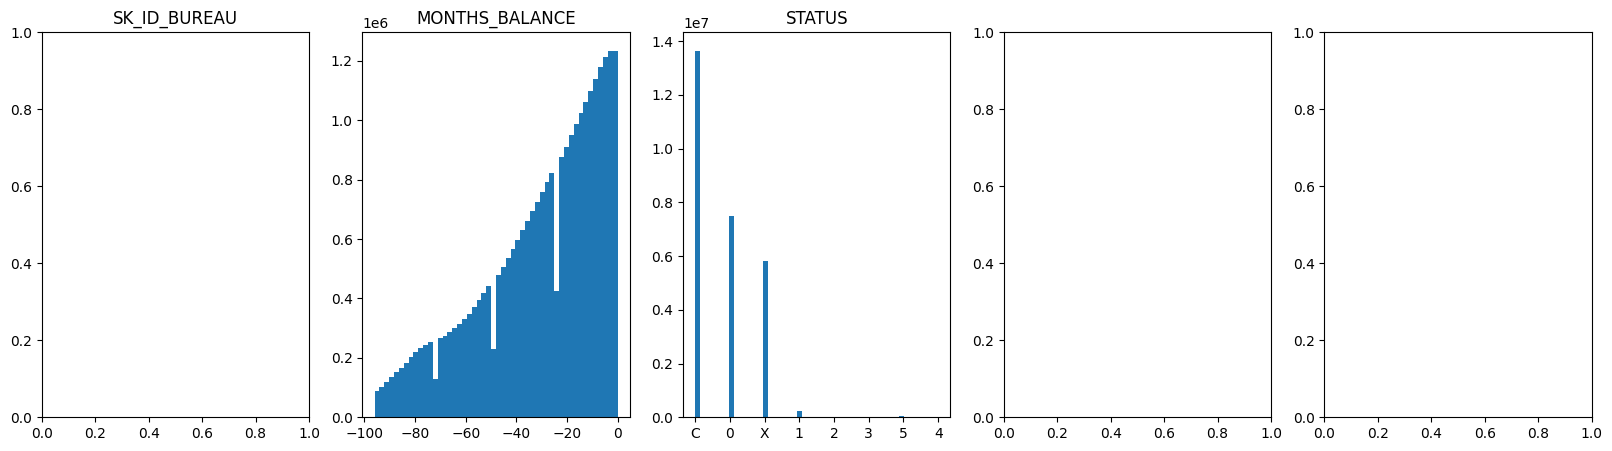

Fichier:  credit_card_balance


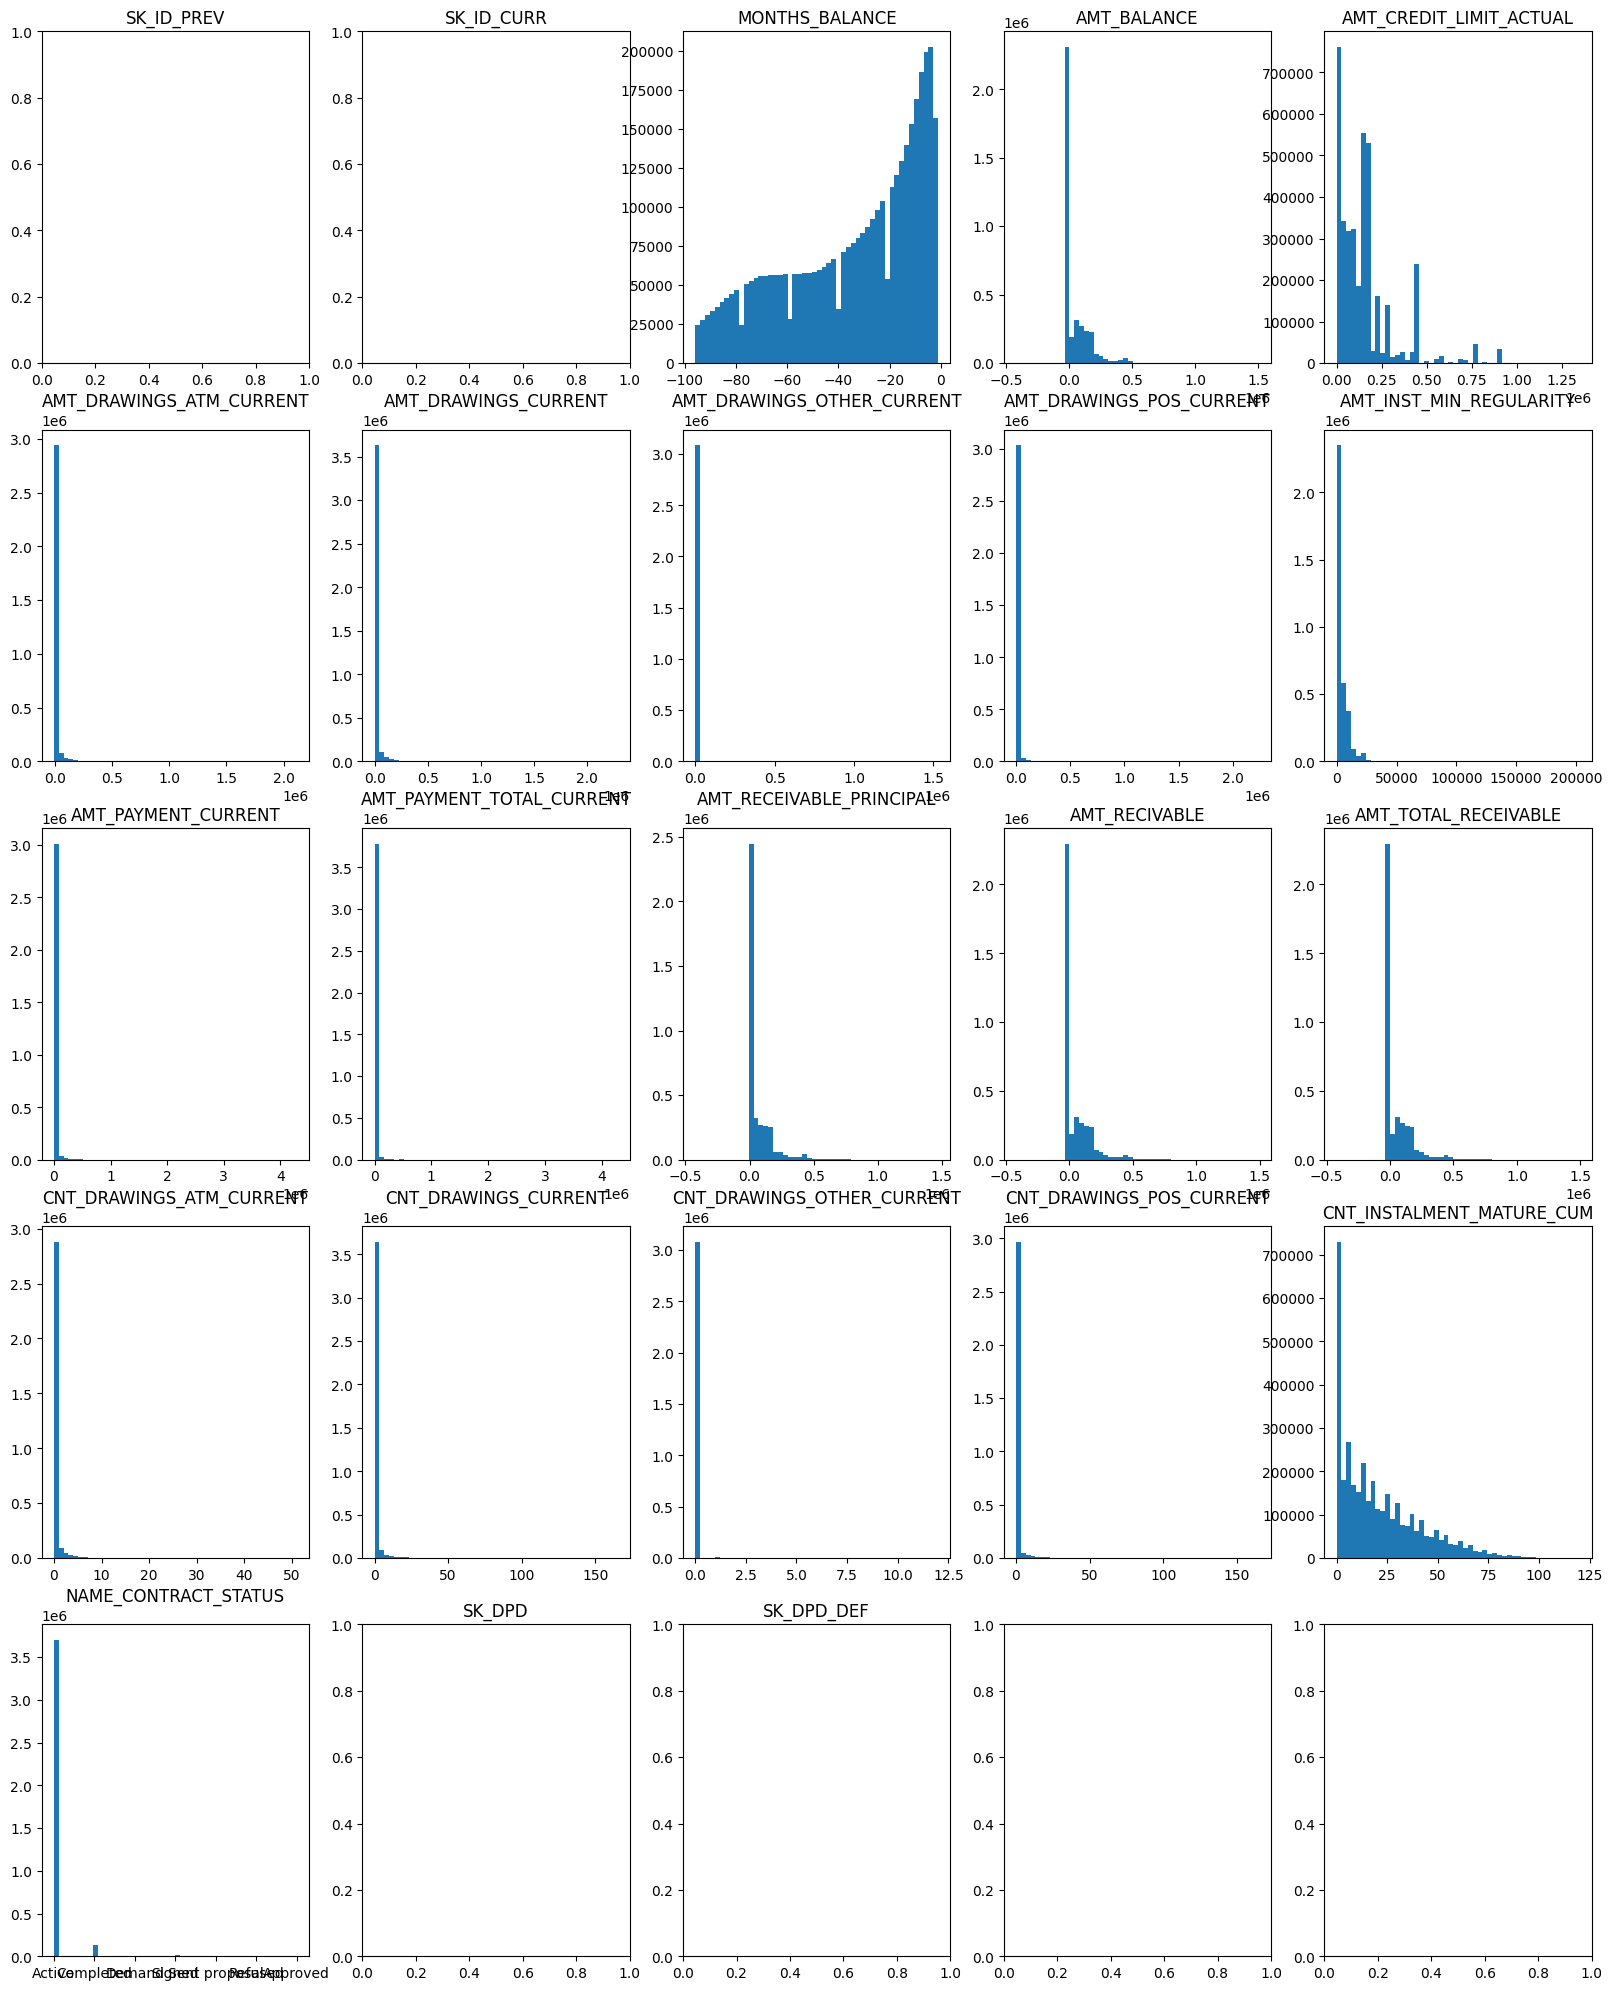

Fichier:  bureau


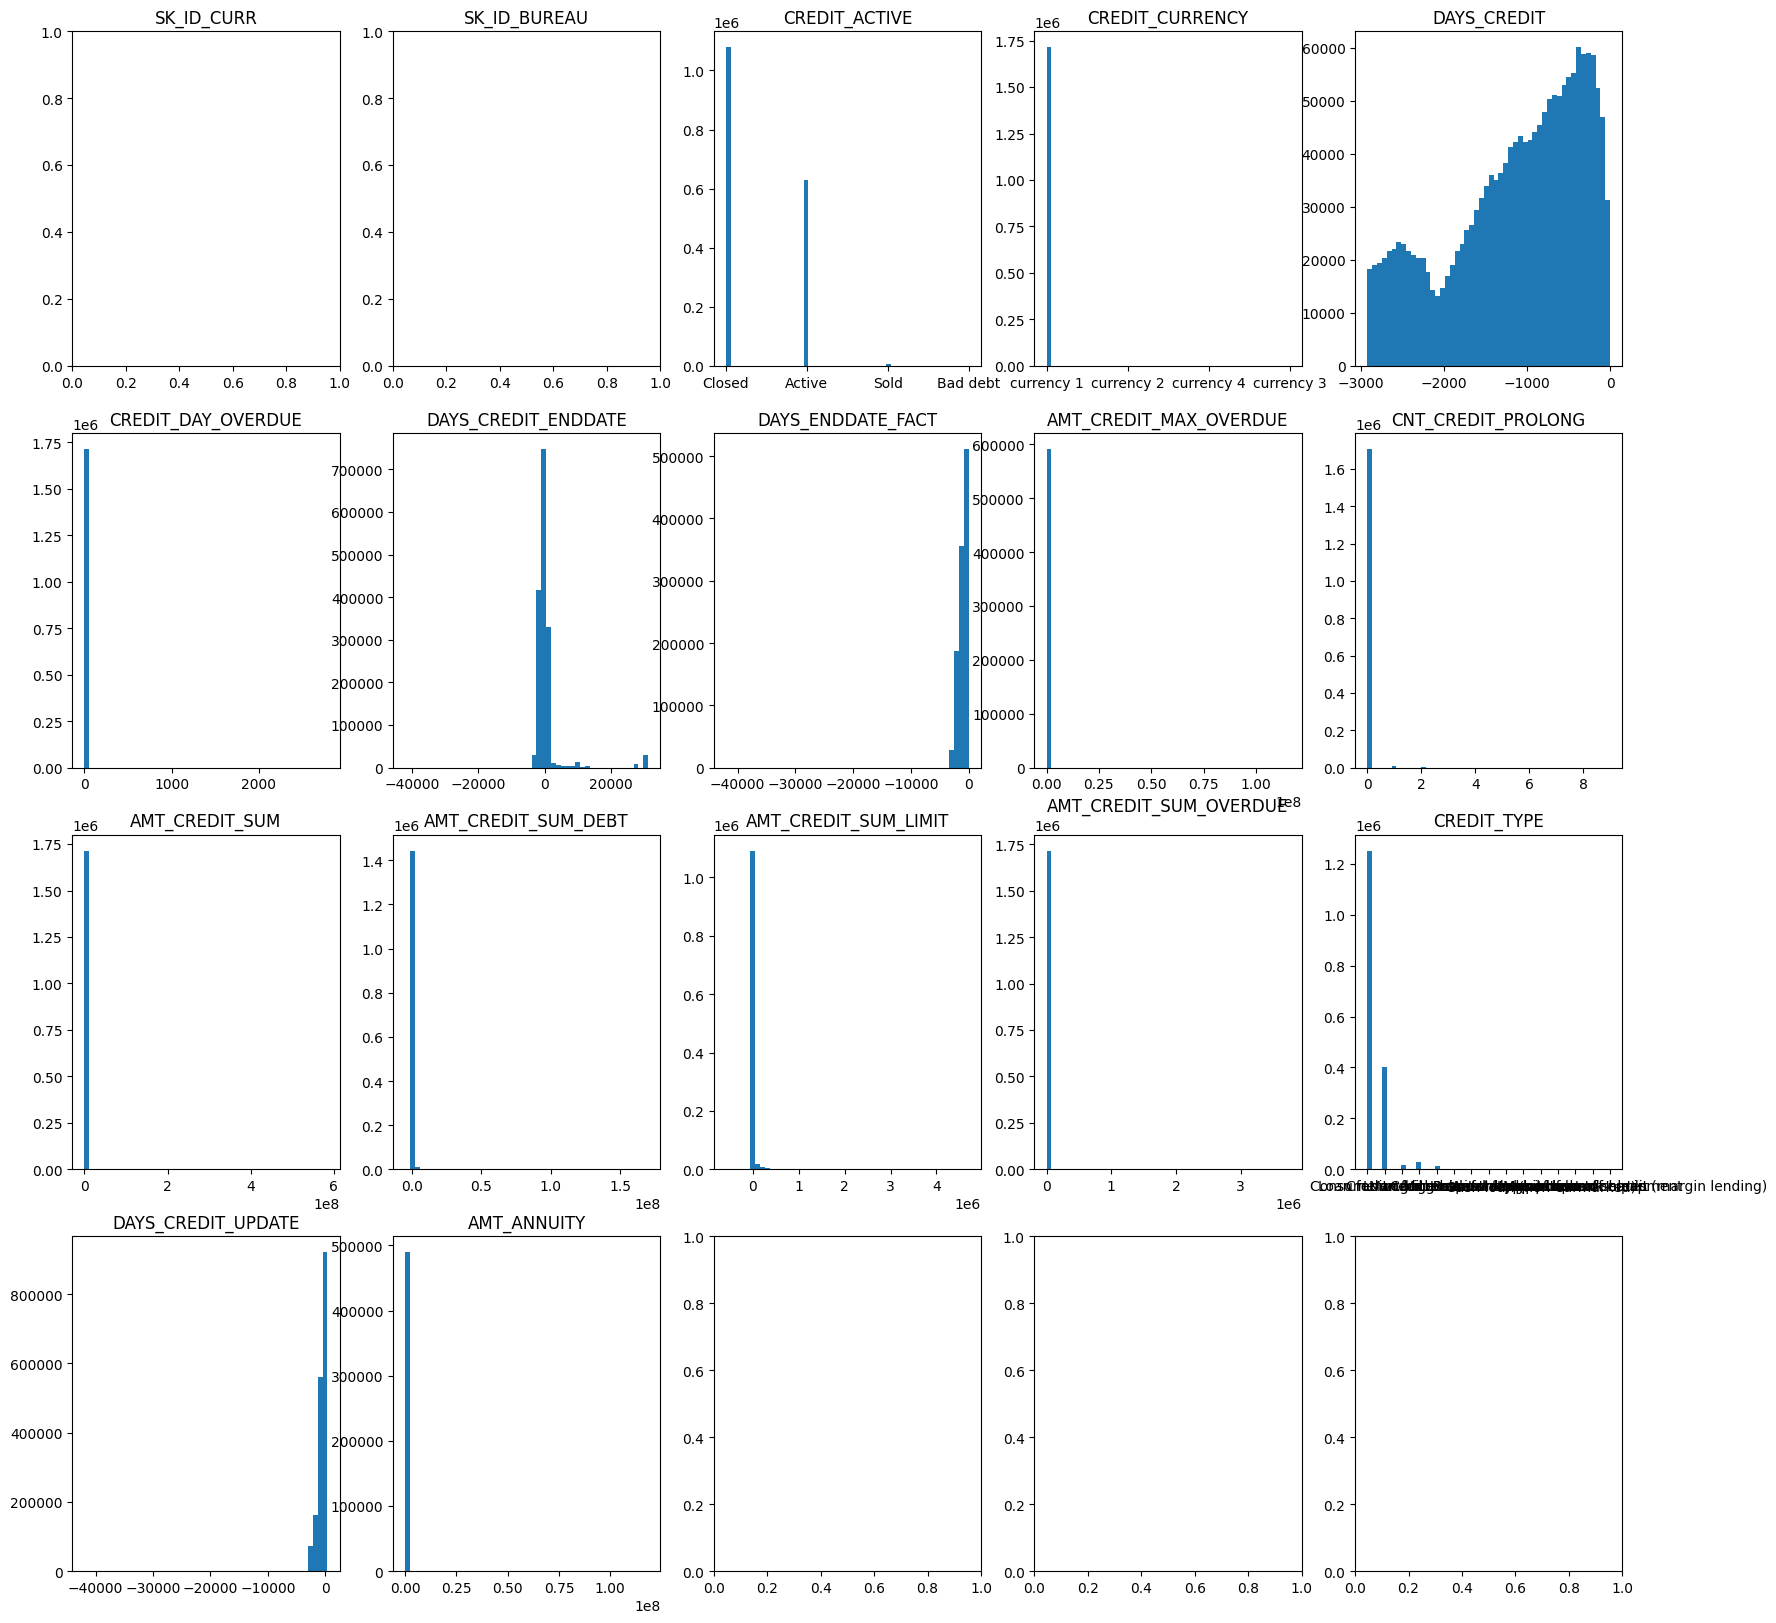

Fichier:  previous_application


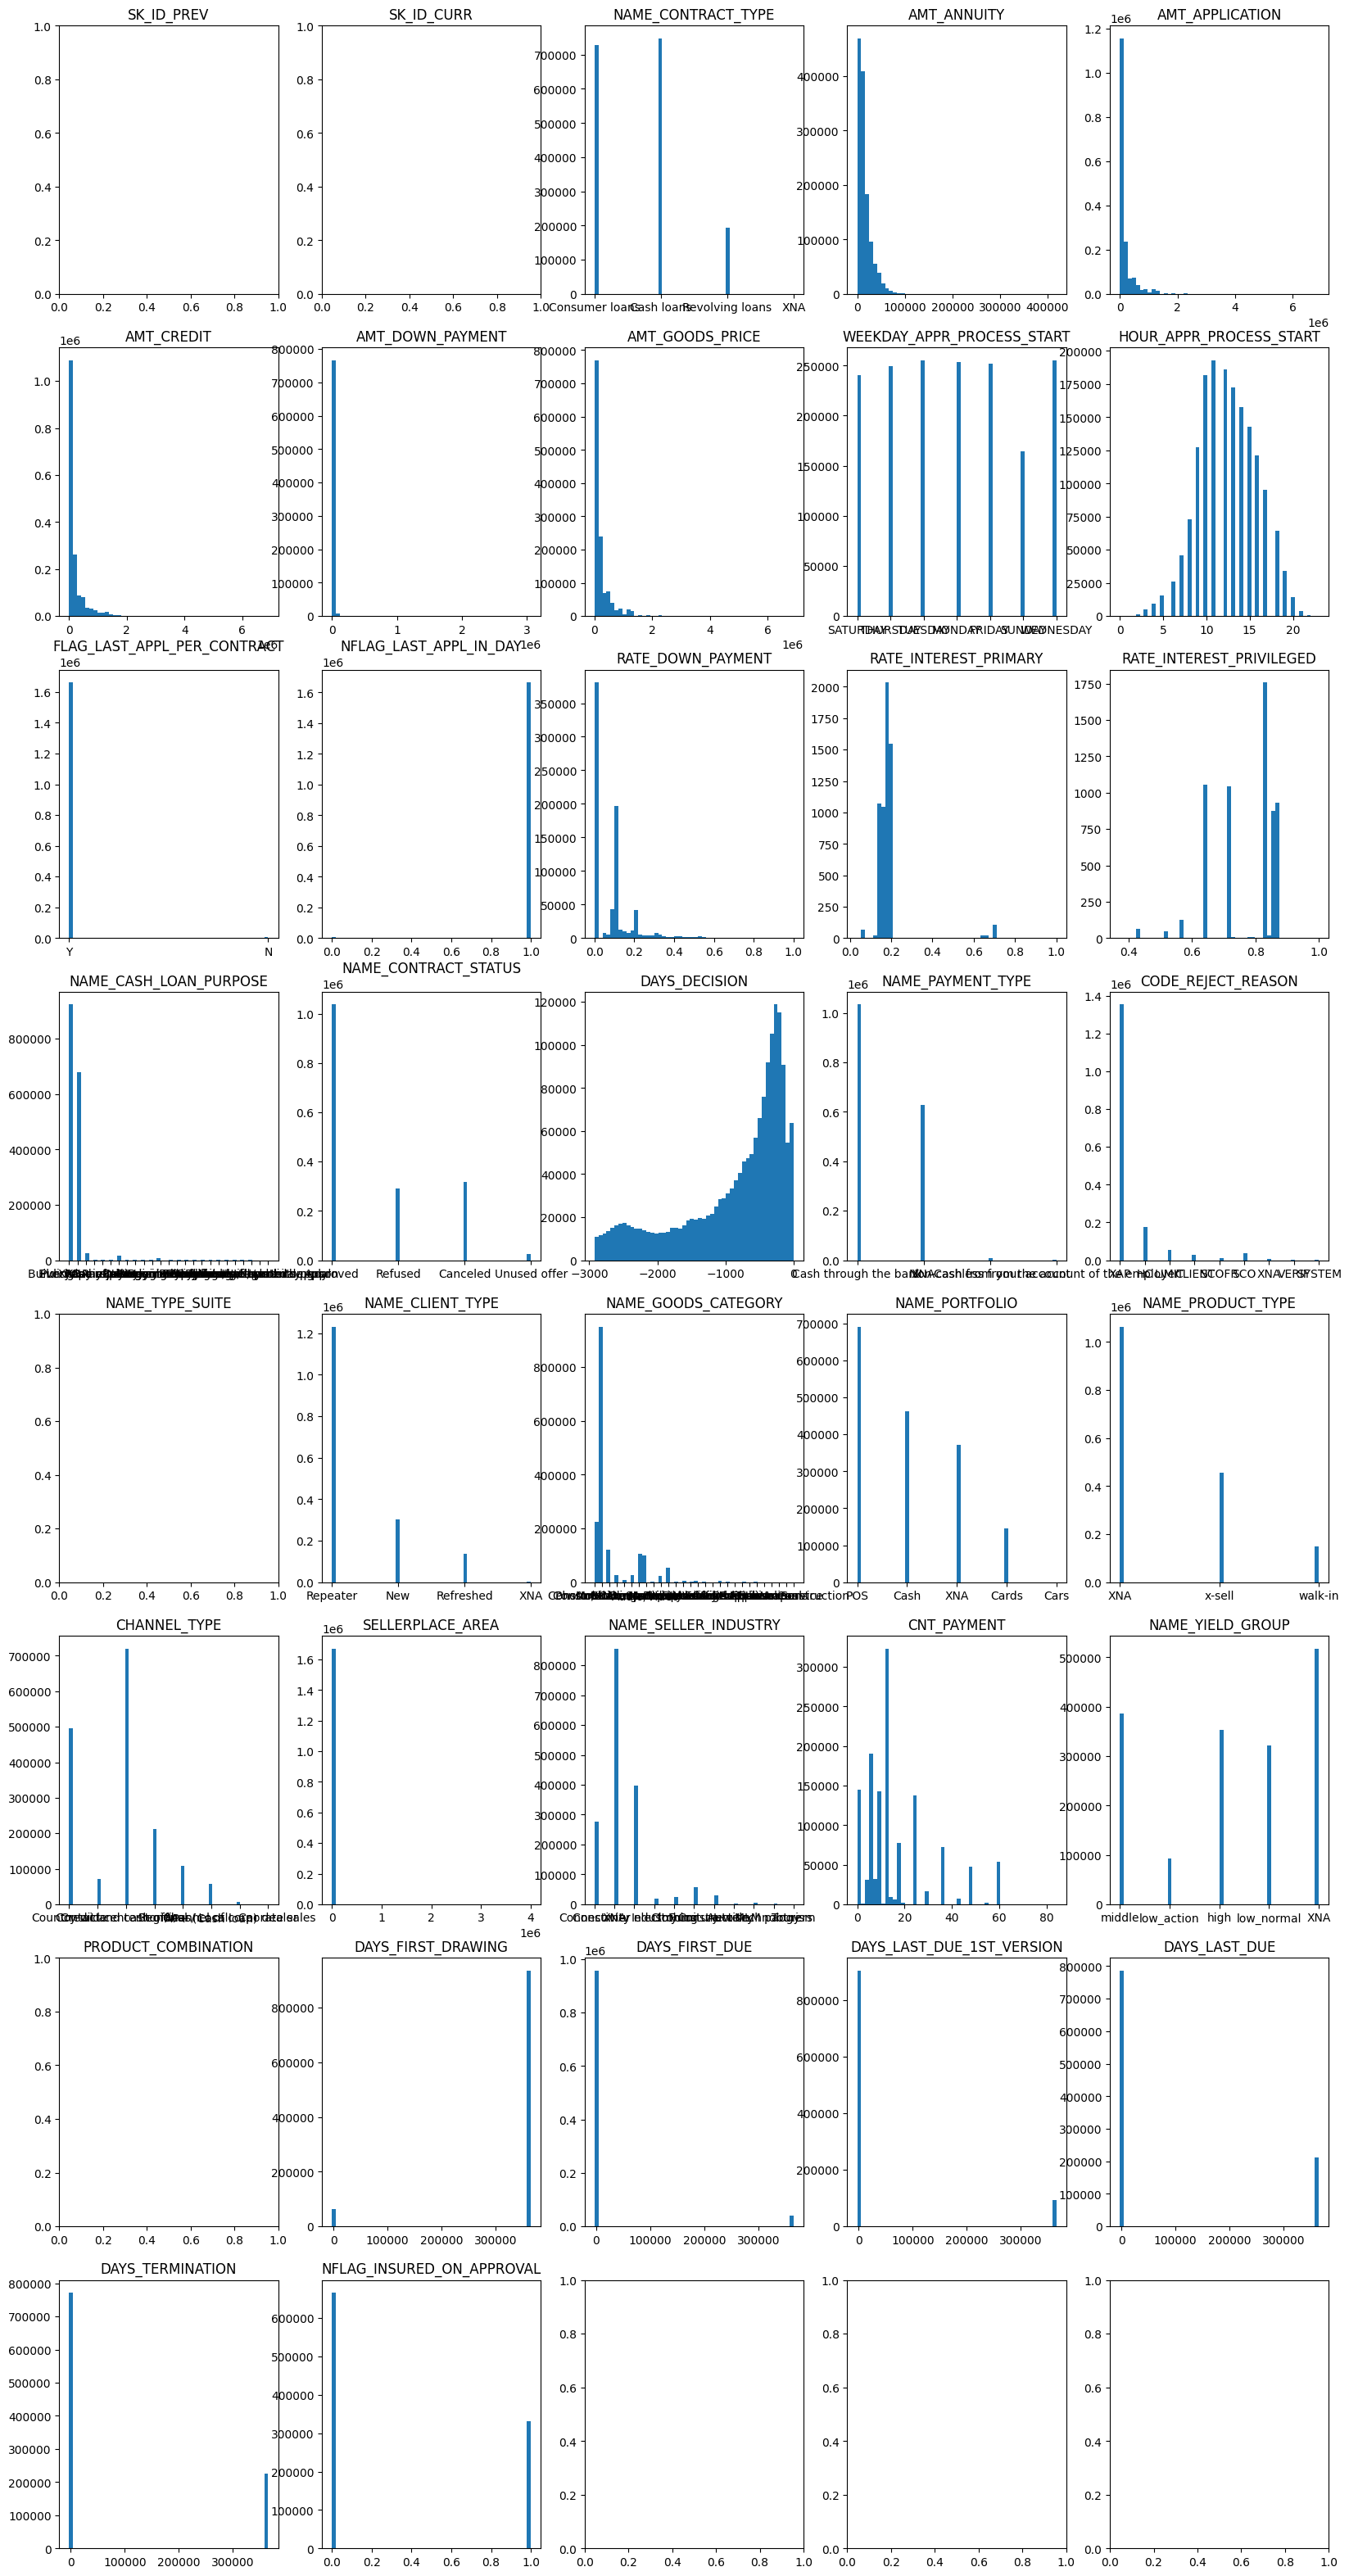

Fichier:  sample_submission


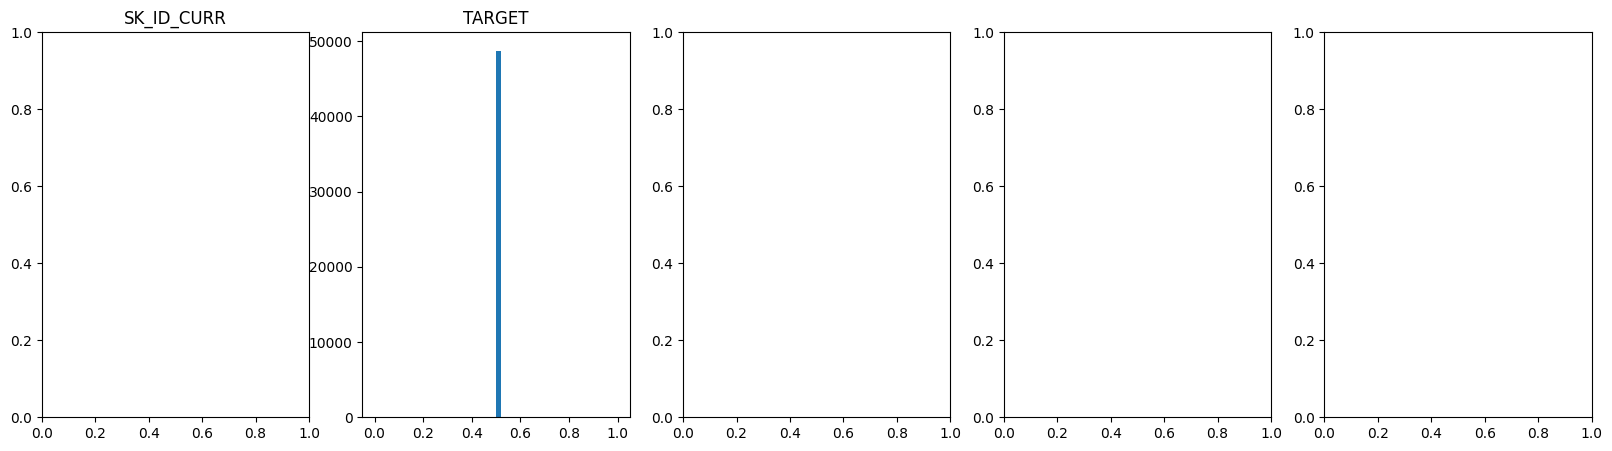

Fichier:  application_train


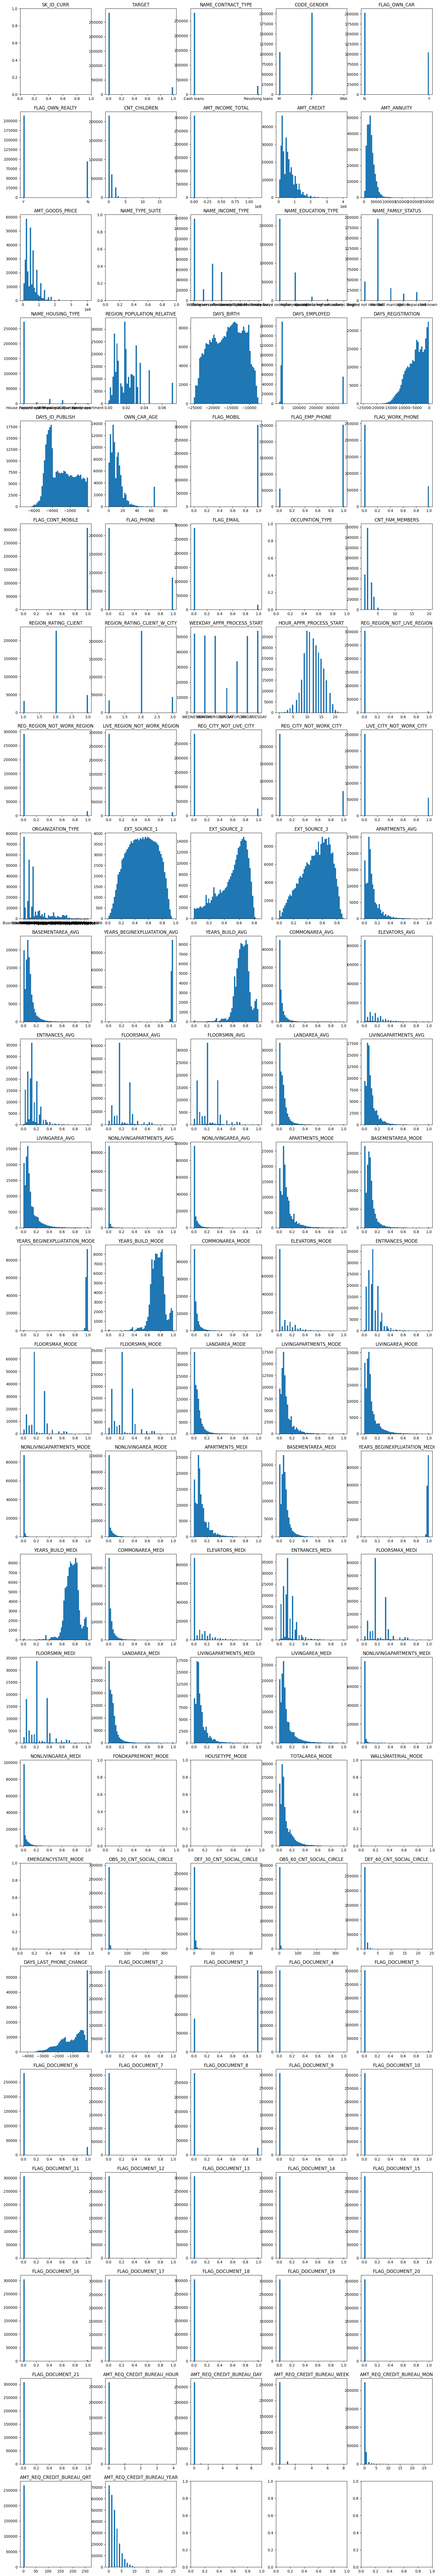

Fichier:  application_test


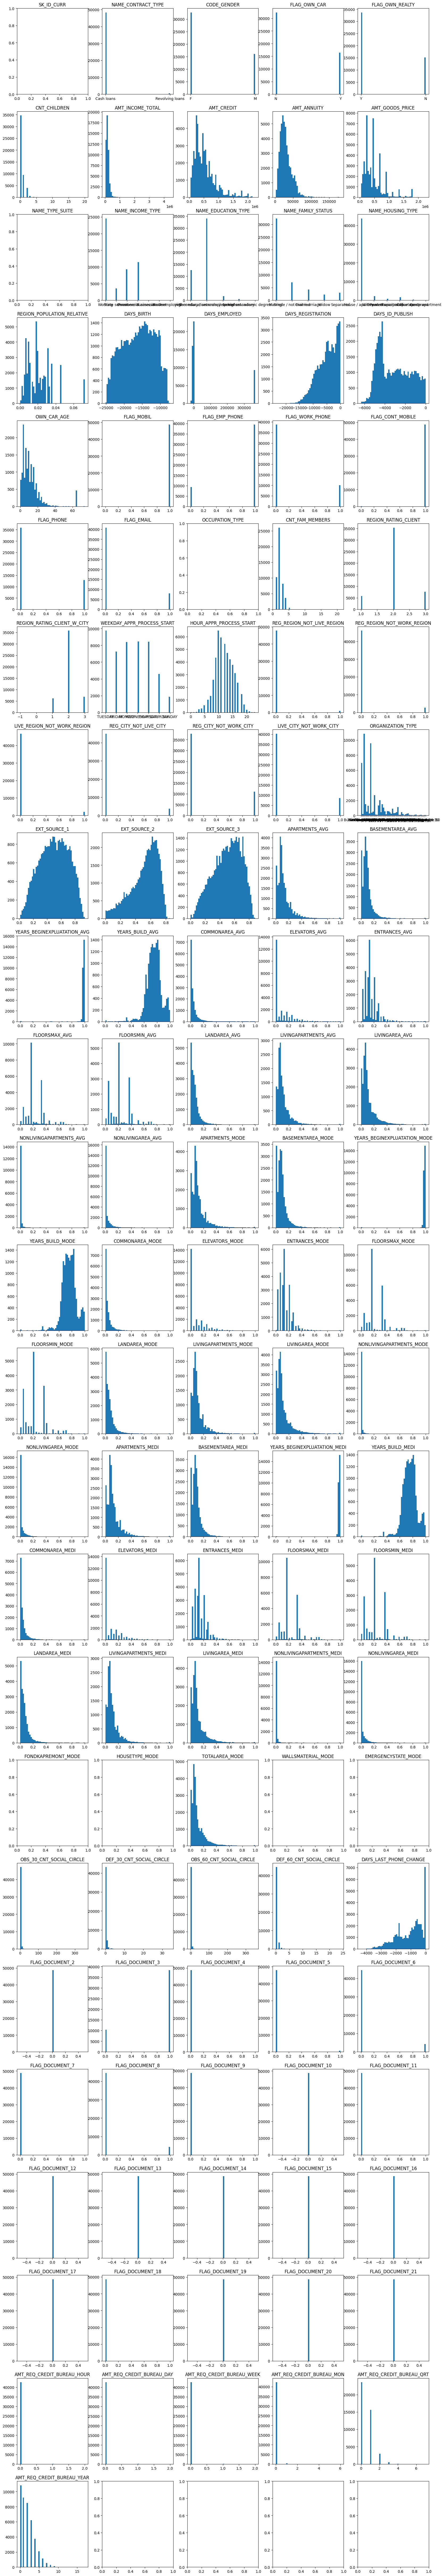

Fichier:  installments_payments


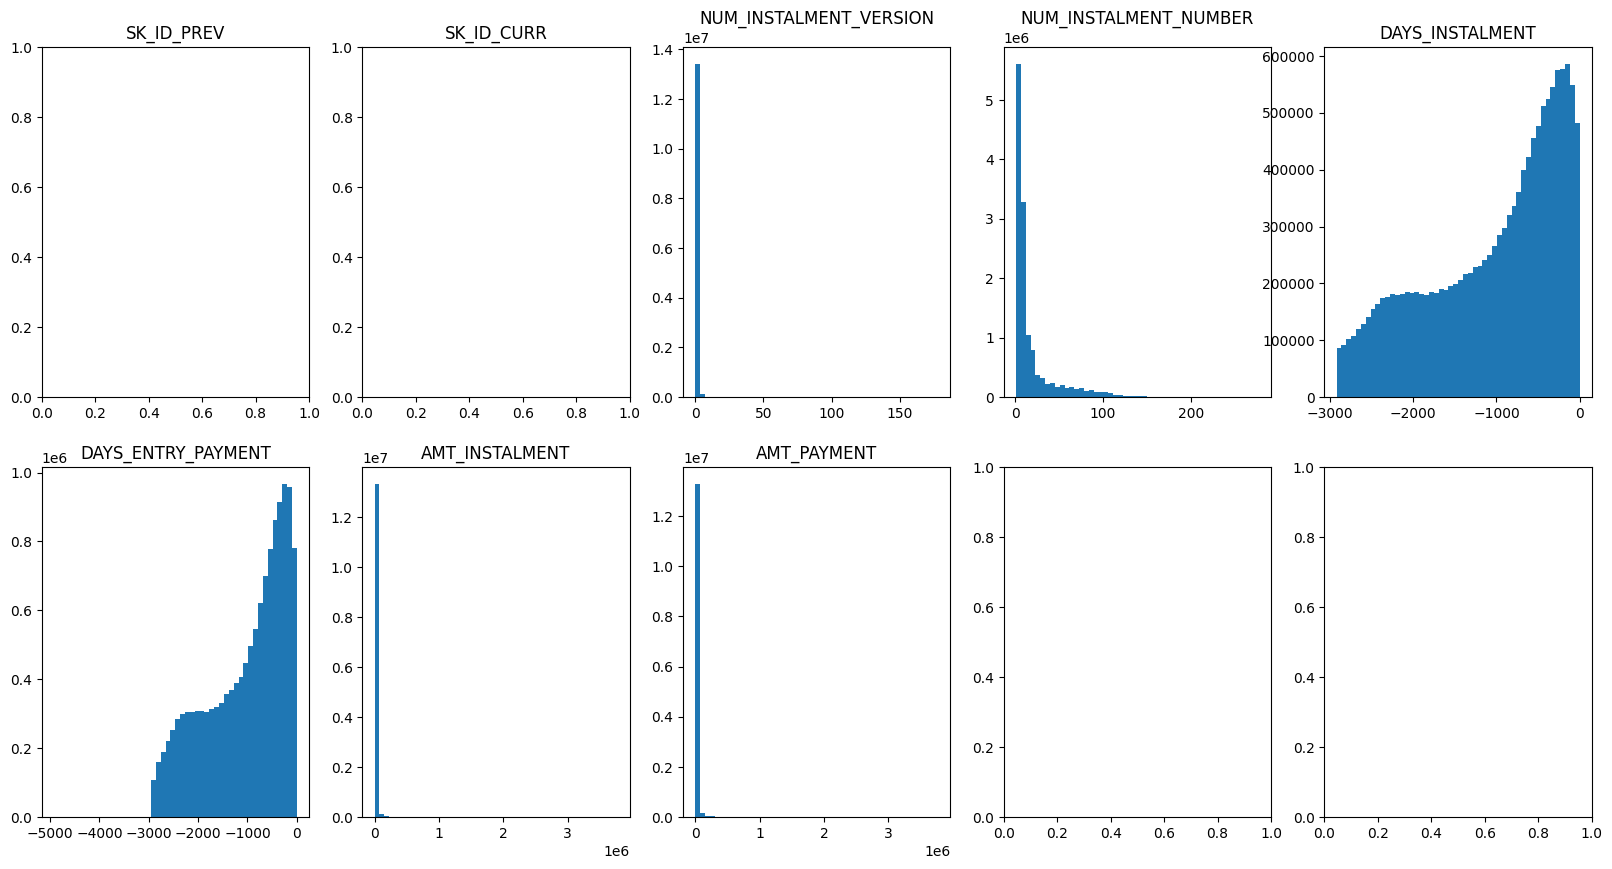

Fichier:  POS_CASH_balance


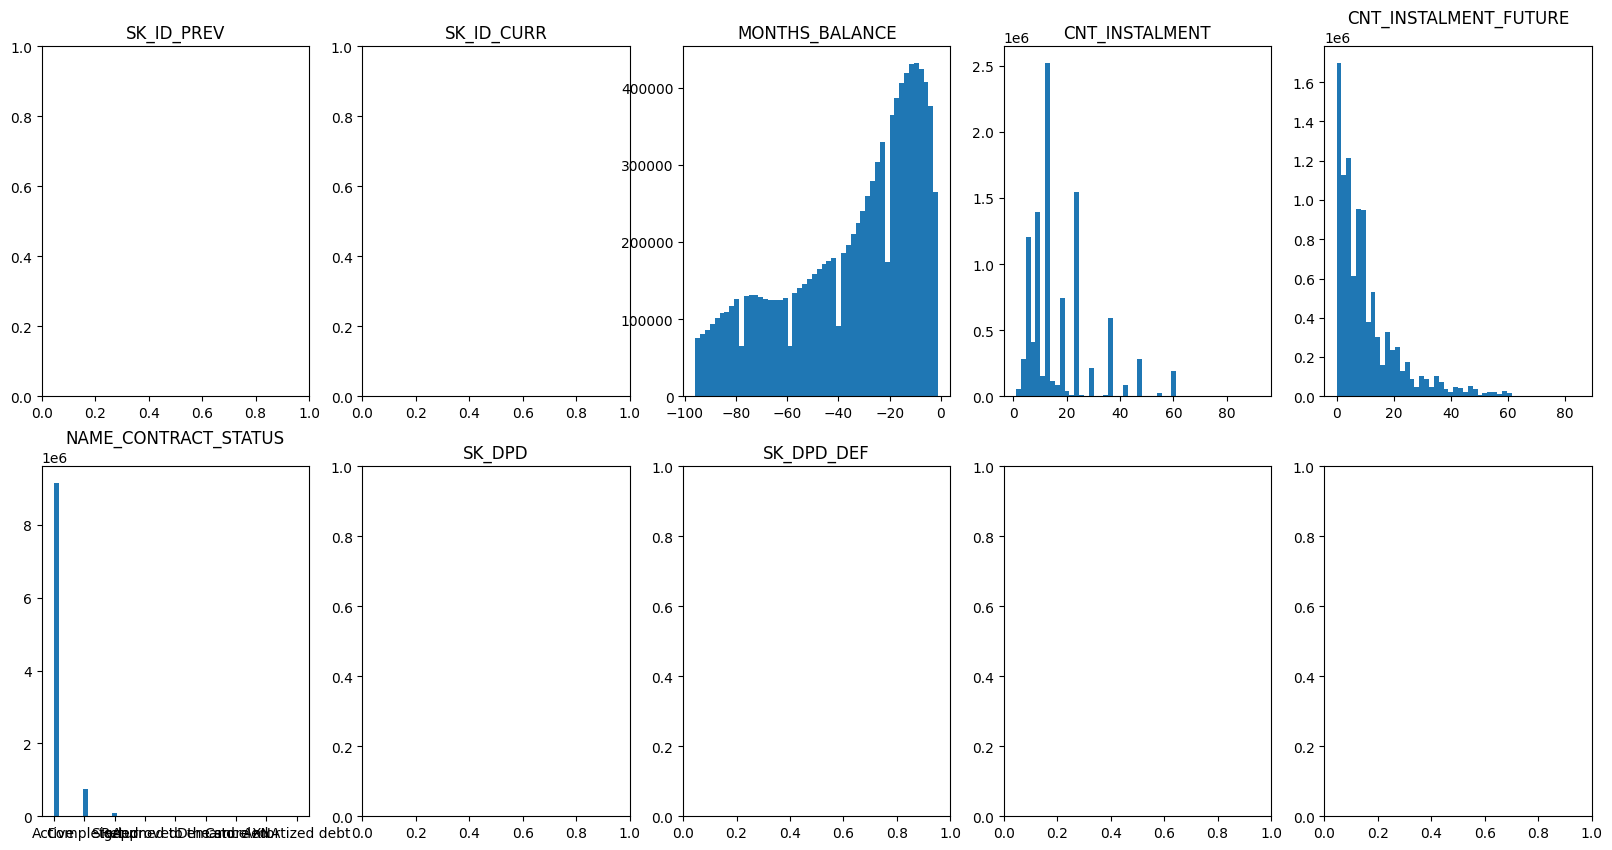

In [4]:
# Visualisation de la distribution des variables
column_index = ['SK_ID_BUREAU', 'SK_ID_PREV', 'SK_ID_CURR', 'SK_DPD', 'SK_DPD_DEF']

def view_histogram(df_brut, column_index):
    """ View histogram """
    for df_name, df_data in df_brut.items():

        nb_column = df_data.shape[1]
        nb_graph_y = 5
        nb_graph_x = int(nb_column / nb_graph_y) + 1
        

        fig, axs = plt.subplots(nb_graph_x, nb_graph_y, figsize=(20, nb_graph_x * 5))
        axs = axs.ravel()
        
        for i, column in enumerate(df_data.columns):
            axs[i].set_title(column)
            if column in column_index:
                continue
                
            try:    
                axs[i].hist(df_data[column], bins=50)
            except:
                continue
        print('Fichier: ', df_name)
        plt.show()
        

view_histogram(df_brut, column_index)

### Analyse de la variable cible

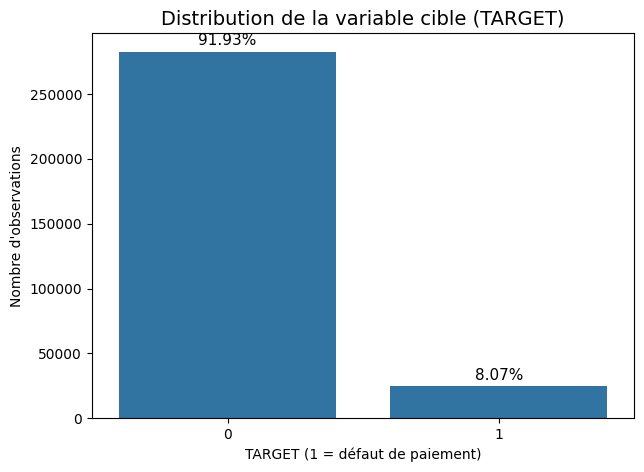

Répartition de la cible :
TARGET
0    91.93 %
1     8.07 %
Name: proportion, dtype: object


In [7]:

plt.figure(figsize=(7, 5))
df_train = df_brut['application_train']

sns.countplot(data=df_train, x='TARGET')
plt.title('Distribution de la variable cible (TARGET)', fontsize=14)
plt.xlabel('TARGET (1 = défaut de paiement)')
plt.ylabel('Nombre d\'observations')

total = len(df_train)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=11, xytext=(0, 8),
                       textcoords='offset points')

plt.show()

print("Répartition de la cible :")
print(df_train['TARGET'].value_counts(normalize=True)
      .mul(100)
      .round(2)
      .astype(str) + " %")


### Prétraitement des données

- ajout des features
- modification et adaptation des données

La partie preprocess est isolé dans un containeur Conda pour assurer la reproductibilité des données.

Elle est disponible dans le fichier src/data/preprocess.py
Elle sauvegarde le dataframe obtenue dans un fichier (parquet) dans le repertoire data/preprocessed


In [13]:
# répertoire de l'entrée MLproject
cwd = Path.cwd()
init_mlflow_dir = str(cwd.parent.resolve()) + "/src/data"
print("Répertoire de l'entrée MLproject:\n", init_mlflow_dir)

result_mlflow = mlflow.run(
                        uri=init_mlflow_dir,
                        entry_point="main",
                        parameters={
                            "output_filename": "application_train_processed.parquet",
                            "data_dir": DATA_DIR,
                            },
                        )

Répertoire de l'entrée MLproject:
 /home/joannes/Documents/openclassroom/06_Initiez_vous_au_MLOps_1-2/openclassrooms_projet06/src/data


2026/02/18 13:51:19 INFO mlflow.utils.conda: Conda environment mlflow-268a00630702738c4cb0157abdc884dd5f7572dd already exists.
2026/02/18 13:51:19 INFO mlflow.projects.utils: === Created directory /tmp/tmp0nr4a3ua for downloading remote URIs passed to arguments of type 'path' ===
2026/02/18 13:51:19 INFO mlflow.projects.backend.local: === Running command 'source /home/joannes/miniconda3/bin/../etc/profile.d/conda.sh && conda activate mlflow-268a00630702738c4cb0157abdc884dd5f7572dd 1>&2 && python preprocess.py  --data_dir /home/joannes/data  --output_filename application_train_processed.parquet
' in run with ID '5a97fed155904f78bfe2928d70232841' === 
2026/02/18 13:51:27 INFO mlflow.projects: === Run (ID '5a97fed155904f78bfe2928d70232841') succeeded ===



=== Chargement des données === /home/joannes/data
data_dir: /home/joannes/data
Chargement de /home/joannes/data/raw/application_train.csv...
Shape: (307511, 122)
Mémoire: 504.99 MB
Shape: (307511, 122)
Valeurs manquantes: 9152465

=== Preprocessing ===
Suppression des colonnes (> 50.0% manquant): 41
Shape: (307511, 81)
Valeurs manquantes: 0

=== Sauvegarde ===
DataFrame sauvegardé: /home/joannes/data/processed/application_train_processed.parquet
Shape: (307511, 81)
Mémoire: 381.40 MB
Terminé!


In [15]:
# Vérification
output_file = DATA_DIR + "/processed/application_train_processed.parquet"
df_prepossessed = pd.read_parquet(output_file)

print(df_prepossessed.head())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             